## Setup

In [1]:
import sys
from pathlib import Path
project_root = Path.cwd()
if project_root.name == "notebooks":
    project_root = project_root.parent
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

In [2]:
import random
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from torch import nn
from torch.utils.data import DataLoader
from src.data_processing import chronological_split
from src.datasets import TabularMovieDataset
from src.evaluation import evaluate_classifier
from src.models import TextMLP
from src.text_embeddings import (
    generate_synopsis_embeddings,
    save_embeddings)
from src.training import (
    count_trainable_parameters,
    fit_classifier,
    predict_classifier,
    set_random_seed)

/Users/ranacopty/Desktop/APS360/aps360-movie-flop-predictor/.venv/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Load dataset

In [51]:
from sklearn.model_selection import train_test_split

df = pd.read_csv(
    project_root / "data/processed/movies_processed.csv",
    parse_dates=["release_date"],
)

# Reserve all 2014+ movies as the chronological test set
development = df[
    df["release_year"] < 2014
].copy()

test = df[
    df["release_year"] >= 2014
].copy()

# Randomly split the pre-2014 development data into train and validation
train, validation = train_test_split(
    development,
    test_size=185,
    stratify=development["flop"],
    random_state=42,
)

# Reset indices for cleaner downstream processing
train = train.reset_index(drop=True)
validation = validation.reset_index(drop=True)
test = test.reset_index(drop=True)

print("Train:", len(train))
print("Validation:", len(validation))
print("Test:", len(test))

print("\nFlop proportions:")
print("Train:", train["flop"].mean())
print("Validation:", validation["flop"].mean())
print("Test:", test["flop"].mean())

assert len(train) == 559
assert len(validation) == 185
assert len(test) == 113

Train: 559
Validation: 185
Test: 113

Flop proportions:
Train: 0.5813953488372093
Validation: 0.5783783783783784
Test: 0.40707964601769914


## Movie overview column

In [52]:
print("Overview column available:", "overview" in df.columns)
print("Missing overviews:", df["overview"].isna().sum())
print(
    "Empty overviews:",
    df["overview"].fillna("").str.strip().eq("").sum(),
)
display(df[["title", "overview"]].head())

Overview column available: True
Missing overviews: 0
Empty overviews: 0


,title,overview
0,Metropolis,In a futuristic city sharply divided between t...
1,Superman,Mild-mannered Clark Kent works as a reporter a...
2,Superman II,Three escaped criminals from the planet Krypto...
3,The Cotton Club,The story of the people that frequented Harlem...
4,Ishtar,Two terrible lounge singers get booked to play...


In [53]:
overview_word_counts = (
    df["overview"]
    .fillna("")
    .str.split()
    .str.len()
)
print(overview_word_counts.describe())

count    857.000000
mean      53.857643
std       25.161270
min       11.000000
25%       35.000000
50%       52.000000
75%       66.000000
max      174.000000
Name: overview, dtype: float64


## Generate embeddings

In [54]:
embedding_path = (
    project_root
    / "data/processed/synopsis_embeddings.npy"
)
if embedding_path.exists():
    synopsis_embeddings = np.load(embedding_path)
    print("Loaded existing embeddings.")
else:
    synopsis_embeddings = generate_synopsis_embeddings(
        df["overview"],
        batch_size=32,
        device="cpu",
    )
    save_embeddings(
        synopsis_embeddings,
        embedding_path,
    )
    print("Generated and saved embeddings.")

Loaded existing embeddings.


In [55]:
print("Embedding shape:", synopsis_embeddings.shape)
print("Contains NaN:", np.isnan(synopsis_embeddings).any())
print("Data type:", synopsis_embeddings.dtype)

Embedding shape: (857, 384)
Contains NaN: False
Data type: float32


## Embedding splits

In [56]:
x_text_train = synopsis_embeddings[
    train.index.to_numpy()]
x_text_validation = synopsis_embeddings[
    validation.index.to_numpy()]
y_train = train["flop"].to_numpy(dtype=np.float32)
y_validation = validation["flop"].to_numpy(dtype=np.float32)
print("Training embeddings:", x_text_train.shape)
print("Validation embeddings:", x_text_validation.shape)

Training embeddings: (559, 384)
Validation embeddings: (185, 384)


In [57]:
from sklearn.decomposition import PCA
text_pca = PCA(
    n_components=64,
    random_state=1024)
x_text_train_reduced = text_pca.fit_transform(x_text_train)
x_text_validation_reduced = text_pca.transform(
    x_text_validation)

print(
    "Variance retained:",
    text_pca.explained_variance_ratio_.sum())

Variance retained: 0.6783776


In [58]:
print("Reduced train shape:", x_text_train_reduced.shape)
print("Reduced validation shape:", x_text_validation_reduced.shape)

Reduced train shape: (559, 64)
Reduced validation shape: (185, 64)


In [59]:
# create datasets and loaders
text_train_dataset = TabularMovieDataset(
    features=x_text_train.astype(np.float32),
    labels=y_train.astype(np.float32),
)
text_validation_dataset = TabularMovieDataset(
    features=x_text_validation.astype(np.float32),
    labels=y_validation.astype(np.float32),
)
text_train_loader = DataLoader(
    text_train_dataset,
    batch_size=32,
    shuffle=True,
)
text_validation_loader = DataLoader(
    text_validation_dataset,
    batch_size=64,
    shuffle=False,
)

## Create text model

In [60]:
set_random_seed(1024)
text_model = TextMLP(
    embedding_dim=x_text_train.shape[1],
    hidden_dim_1=16,
    hidden_dim_2=8,
    dropout=0.5,
)
print(text_model)
print(
    "Trainable parameters:",
    count_trainable_parameters(text_model),
)

TextMLP(
  (network): Sequential(
    (0): Linear(in_features=384, out_features=16, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.5, inplace=False)
    (3): Linear(in_features=16, out_features=8, bias=True)
    (4): ReLU()
    (5): Dropout(p=0.5, inplace=False)
    (6): Linear(in_features=8, out_features=1, bias=True)
  )
)
Trainable parameters: 6305


## Train model

In [61]:
if torch.backends.mps.is_available():
    device = torch.device("mps")
elif torch.cuda.is_available():
    device = torch.device("cuda")
else:
    device = torch.device("cpu")
print("Training device:", device)

Training device: mps


In [62]:
loss_function = nn.BCEWithLogitsLoss()
optimizer = torch.optim.Adam(
    text_model.parameters(),
    lr=1e-3,
    weight_decay=1e-4,
)
history = fit_classifier(
    model=text_model,
    train_loader=text_train_loader,
    validation_loader=text_validation_loader,
    optimizer=optimizer,
    loss_function=loss_function,
    device=device,
    max_epochs=100,
    patience=12,
)
print("Epochs trained:", history["epochs_trained"])
print(
    "Best validation loss:",
    history["best_validation_loss"],
)

Epochs trained: 26
Best validation loss: 0.6797856595065143


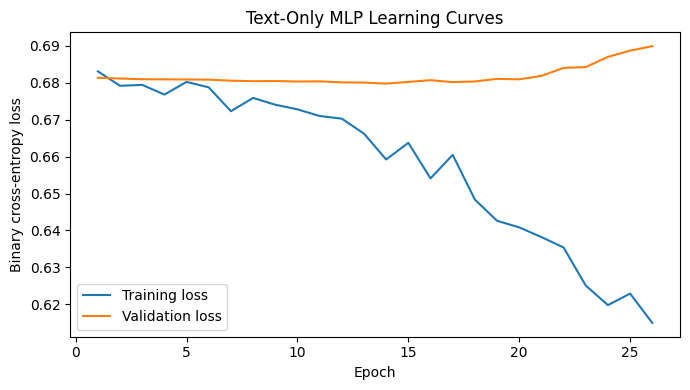

In [63]:
epochs = np.arange(
    1,
    history["epochs_trained"] + 1)
plt.figure(figsize=(7, 4))
plt.plot(
    epochs,
    history["train_loss"],
    label="Training loss")
plt.plot(
    epochs,
    history["validation_loss"],
    label="Validation loss",)
plt.xlabel("Epoch")
plt.ylabel("Binary cross-entropy loss")
plt.title("Text-Only MLP Learning Curves")
plt.legend()
plt.tight_layout()
plt.show()

In [64]:
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

text_probe = Pipeline(
    steps=[
        ("scaler", StandardScaler()),
        (
            "classifier",
            LogisticRegression(
                C=0.1,
                max_iter=3000,
                random_state=42,
            ),
        ),
    ]
)

text_probe.fit(
    x_text_train,
    y_train.astype(int),
)

text_probe_pred = text_probe.predict(
    x_text_validation
)

text_probe_prob = text_probe.predict_proba(
    x_text_validation
)[:, 1]

text_probe_metrics = evaluate_classifier(
    y_true=y_validation.astype(int),
    y_pred=text_probe_pred,
    y_prob=text_probe_prob,
)

text_probe_metrics

{'accuracy': 0.5405405405405406,
 'balanced_accuracy': 0.5315720105439732,
 'flop_precision': 0.6057692307692307,
 'flop_recall': 0.5887850467289719,
 'flop_f1': 0.5971563981042654,
 'roc_auc': 0.5173735921399473}

In [65]:
probe_results = []

for C in [0.001, 0.01, 0.1, 1.0]:
    model = Pipeline(
        steps=[
            ("scaler", StandardScaler()),
            (
                "classifier",
                LogisticRegression(
                    C=C,
                    max_iter=3000,
                    random_state=42,
                ),
            ),
        ]
    )

    model.fit(
        x_text_train,
        y_train.astype(int),
    )

    predictions = model.predict(
        x_text_validation
    )

    probabilities = model.predict_proba(
        x_text_validation
    )[:, 1]

    metrics = evaluate_classifier(
        y_true=y_validation.astype(int),
        y_pred=predictions,
        y_prob=probabilities,
    )

    probe_results.append(
        {
            "C": C,
            **metrics,
        }
    )

probe_results = pd.DataFrame(probe_results)
display(probe_results.round(3))

,C,accuracy,balanced_accuracy,flop_precision,flop_recall,flop_f1,roc_auc
0,0.001,0.551,0.494,0.575,0.860,0.689,0.561
1,0.010,0.595,0.580,0.643,0.673,0.658,0.552
2,0.100,0.541,0.532,0.606,0.589,0.597,0.517
3,1.000,0.497,0.491,0.570,0.533,0.551,0.488


## Run tabular experiment

In [68]:
def run_text_experiment(
    architecture_name,
    hidden_dim_1,
    hidden_dim_2,
    dropout,
    seed,
):
    """Train and evaluate one text-only MLP configuration."""
    set_random_seed(seed)
    # Recreate the shuffled loader for every seed
    loader_generator = torch.Generator()
    loader_generator.manual_seed(seed)
    experiment_train_loader = DataLoader(
        text_train_dataset,
        batch_size=32,
        shuffle=True,
        generator=loader_generator)
    experiment_validation_loader = DataLoader(
        text_validation_dataset,
        batch_size=64,
        shuffle=False)
    # Create a new model for every experiment
    experiment_model = TextMLP(
        embedding_dim=x_text_train.shape[1],
        hidden_dim_1=hidden_dim_1,
        hidden_dim_2=hidden_dim_2,
        dropout=dropout)
    loss_function = nn.BCEWithLogitsLoss()
    # Create a new optimizer for every experiment
    optimizer = torch.optim.Adam(
        experiment_model.parameters(),
        lr=1e-3,
        weight_decay=1e-4)
    history = fit_classifier(
        model=experiment_model,
        train_loader=experiment_train_loader,
        validation_loader=experiment_validation_loader,
        optimizer=optimizer,
        loss_function=loss_function,
        device=device,
        max_epochs=100,
        patience=12)
    predictions, probabilities = predict_classifier(
        model=experiment_model,
        loader=experiment_validation_loader,
        device=device)
    metrics = evaluate_classifier(
        y_true=y_validation.astype(int),
        y_pred=predictions,
        y_prob=probabilities)
    result = {
        "architecture": architecture_name,
        "seed": seed,
        "dropout": dropout,
        "parameters": count_trainable_parameters(experiment_model),
        "epochs_trained": history["epochs_trained"],
        "best_validation_loss": history["best_validation_loss"],
        **metrics}

    return result, history

In [69]:
text_architectures = [
    {
        "name": "32-8",
        "hidden_dim_1": 32,
        "hidden_dim_2": 8,
        "dropout": 0.5,
    },
    {
        "name": "16-8",
        "hidden_dim_1": 16,
        "hidden_dim_2": 8,
        "dropout": 0.5,
    },
    {
        "name": "16-4",
        "hidden_dim_1": 16,
        "hidden_dim_2": 4,
        "dropout": 0.5,
    },
]

seeds = [0, 1, 2, 3, 4]

In [70]:
text_experiment_results = []
text_experiment_histories = {}

for architecture in text_architectures:
    for seed in seeds:
        result, history = run_text_experiment(
            architecture_name=architecture["name"],
            hidden_dim_1=architecture["hidden_dim_1"],
            hidden_dim_2=architecture["hidden_dim_2"],
            dropout=architecture["dropout"],
            seed=seed,
        )

        text_experiment_results.append(result)

        text_experiment_histories[
            (architecture["name"], seed)
        ] = history

        print(
            f"{architecture['name']}, seed {seed}: "
            f"balanced accuracy={result['balanced_accuracy']:.3f}, "
            f"flop F1={result['flop_f1']:.3f}, "
            f"ROC-AUC={result['roc_auc']:.3f}"
        )

32-8, seed 0: balanced accuracy=0.500, flop F1=0.733, ROC-AUC=0.551
32-8, seed 1: balanced accuracy=0.504, flop F1=0.687, ROC-AUC=0.564
32-8, seed 2: balanced accuracy=0.500, flop F1=0.733, ROC-AUC=0.552
32-8, seed 3: balanced accuracy=0.477, flop F1=0.679, ROC-AUC=0.552
32-8, seed 4: balanced accuracy=0.492, flop F1=0.722, ROC-AUC=0.546
16-8, seed 0: balanced accuracy=0.499, flop F1=0.725, ROC-AUC=0.560
16-8, seed 1: balanced accuracy=0.512, flop F1=0.687, ROC-AUC=0.566
16-8, seed 2: balanced accuracy=0.500, flop F1=0.733, ROC-AUC=0.561
16-8, seed 3: balanced accuracy=0.495, flop F1=0.729, ROC-AUC=0.551
16-8, seed 4: balanced accuracy=0.495, flop F1=0.699, ROC-AUC=0.534
16-4, seed 0: balanced accuracy=0.500, flop F1=0.733, ROC-AUC=0.563
16-4, seed 1: balanced accuracy=0.500, flop F1=0.733, ROC-AUC=0.500
16-4, seed 2: balanced accuracy=0.497, flop F1=0.727, ROC-AUC=0.568
16-4, seed 3: balanced accuracy=0.501, flop F1=0.712, ROC-AUC=0.541
16-4, seed 4: balanced accuracy=0.517, flop F1=0

In [71]:
text_experiment_results_df = pd.DataFrame(
    text_experiment_results)

display(
    text_experiment_results_df[
        [
            "architecture",
            "seed",
            "dropout",
            "parameters",
            "epochs_trained",
            "accuracy",
            "balanced_accuracy",
            "flop_precision",
            "flop_recall",
            "flop_f1",
            "roc_auc",
        ]
    ].round(3)
)

,architecture,seed,dropout,parameters,epochs_trained,accuracy,balanced_accuracy,flop_precision,flop_recall,flop_f1,roc_auc
0,32-8,0,0.5,12593,26,0.578,0.500,0.578,1.000,0.733,0.551
1,32-8,1,0.5,12593,25,0.557,0.504,0.581,0.841,0.687,0.564
2,32-8,2,0.5,12593,25,0.578,0.500,0.578,1.000,0.733,0.552
3,32-8,3,0.5,12593,26,0.535,0.477,0.565,0.850,0.679,0.552
4,32-8,4,0.5,12593,26,0.568,0.492,0.575,0.972,0.722,0.546
5,16-8,0,0.5,6305,26,0.573,0.499,0.578,0.972,0.725,0.560
6,16-8,1,0.5,6305,30,0.562,0.512,0.586,0.832,0.687,0.566
7,16-8,2,0.5,6305,23,0.578,0.500,0.578,1.000,0.733,0.561
8,16-8,3,0.5,6305,28,0.573,0.495,0.576,0.991,0.729,0.551
9,16-8,4,0.5,6305,28,0.557,0.495,0.576,0.888,0.699,0.534


In [72]:
text_architecture_summary = (
    text_experiment_results_df
    .groupby("architecture")
    .agg(
        parameters=("parameters", "first"),
        balanced_accuracy_mean=(
            "balanced_accuracy",
            "mean",
        ),
        balanced_accuracy_std=(
            "balanced_accuracy",
            "std",
        ),
        flop_f1_mean=("flop_f1", "mean"),
        flop_f1_std=("flop_f1", "std"),
        roc_auc_mean=("roc_auc", "mean"),
        roc_auc_std=("roc_auc", "std"),
        mean_epochs=("epochs_trained", "mean"),
    )
    .reset_index()
)
display(text_architecture_summary.round(3))

,architecture,parameters,balanced_accuracy_mean,balanced_accuracy_std,flop_f1_mean,flop_f1_std,roc_auc_mean,roc_auc_std,mean_epochs
0,16-4,6233,0.503,0.008,0.724,0.010,0.551,0.032,54.8
1,16-8,6305,0.500,0.007,0.714,0.020,0.554,0.013,27.0
2,32-8,12593,0.495,0.011,0.711,0.026,0.553,0.007,25.6
